# 05 — Correlações e Testes de Hipóteses
## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Analisar as correlações entre variáveis numéricas e realizar
testes de hipóteses para validar relações estatisticamente significativas.

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_ind
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'text.color':        'white',
    'axes.titlecolor':   'white',
    'grid.color':        '#2a2a4a',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

INSTA_COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

print(' Setup completo!')

 Setup completo!


In [2]:
# ============================================================
# CARREGAMENTO
# ============================================================
df = pd.read_csv('../data/instagram_usage_lifestyle.csv', nrows=300000)

# Variáveis de interesse
USAGE_VARS = [
    'daily_active_minutes_instagram', 'sessions_per_day',
    'reels_watched_per_day', 'stories_viewed_per_day',
    'time_on_feed_per_day', 'time_on_reels_per_day',
    'posts_created_per_week', 'likes_given_per_day',
    'average_session_length_minutes', 'user_engagement_score'
]

WELLBEING_VARS = [
    'perceived_stress_score', 'self_reported_happiness',
    'sleep_hours_per_night', 'exercise_hours_per_week',
    'daily_steps_count', 'body_mass_index',
    'blood_pressure_systolic', 'blood_pressure_diastolic'
]

USAGE_VARS     = [v for v in USAGE_VARS     if v in df.columns]
WELLBEING_VARS = [v for v in WELLBEING_VARS if v in df.columns]
ALL_VARS       = USAGE_VARS + WELLBEING_VARS

print(f' Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f' Variáveis de uso      : {len(USAGE_VARS)}')
print(f' Variáveis de bem-estar: {len(WELLBEING_VARS)}')

 Dataset carregado: 300,000 linhas × 58 colunas
 Variáveis de uso      : 10
 Variáveis de bem-estar: 8


 MATRIZ DE COVARIÂNCIA (primeiras 6 variáveis)
────────────────────────────────────────────────────────────
                                daily_active_minutes_instagram  sessions_per_day  reels_watched_per_day  stories_viewed_per_day  time_on_feed_per_day  time_on_reels_per_day
daily_active_minutes_instagram                       12125.416           654.744               7334.834                4075.709              6061.691               3639.782
sessions_per_day                                       654.744            63.211                395.591                 219.878               327.687                196.484
reels_watched_per_day                                 7334.834           395.591               5802.804                2509.788              3667.263               2202.335
stories_viewed_per_day                                4075.709           219.878               2509.788                1502.121              2037.231               1224.017
time_on_feed_per_day       

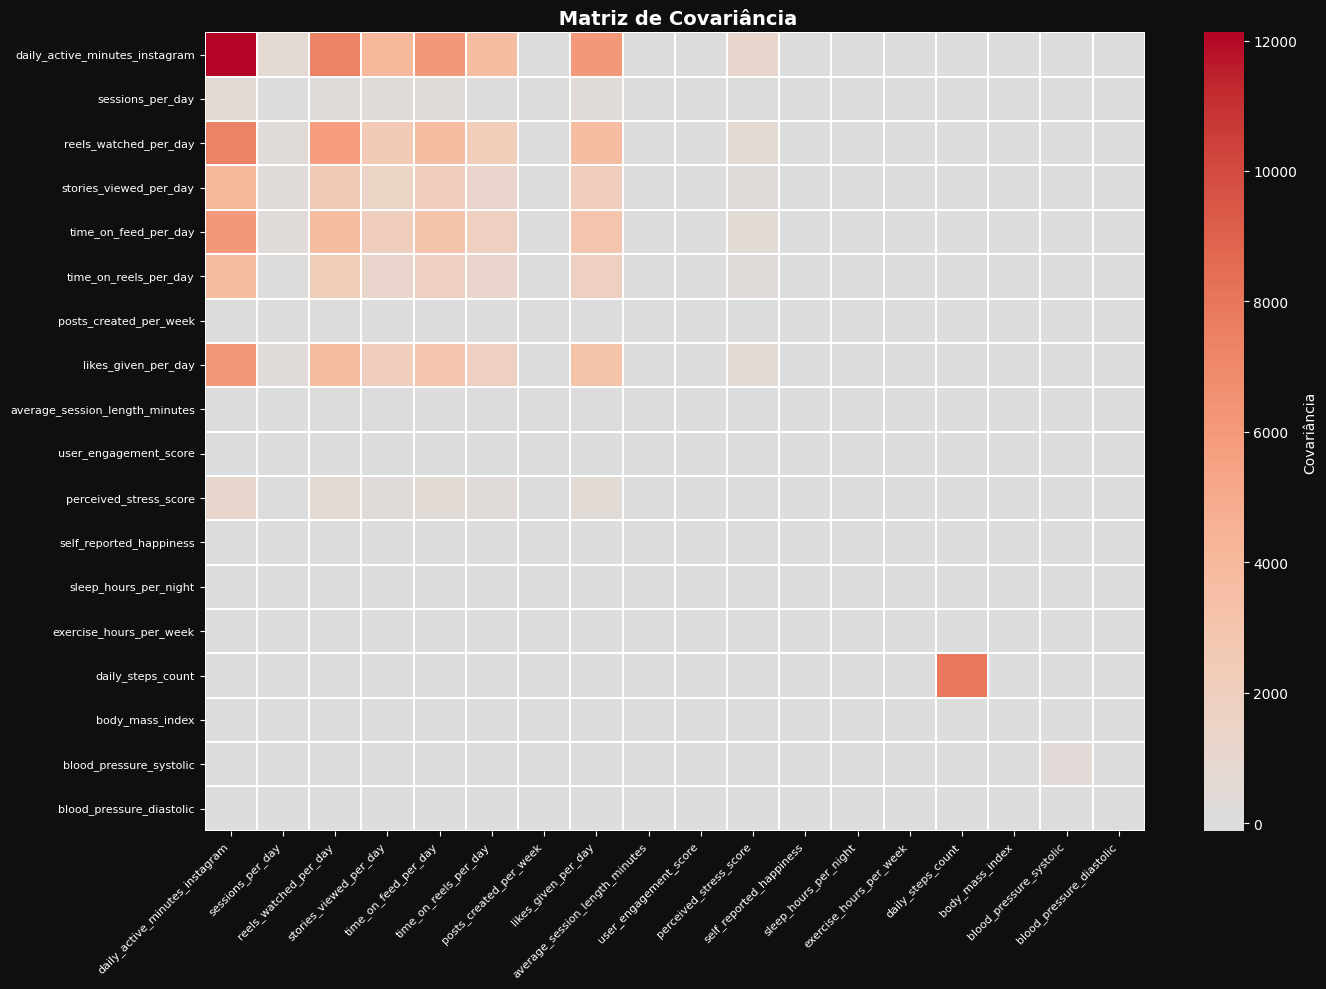

 Guardado: fig_covariancia.png


In [3]:
# ============================================================
# MATRIZ DE COVARIÂNCIA
# ============================================================

cov_matrix = df[ALL_VARS].cov()

print(' MATRIZ DE COVARIÂNCIA (primeiras 6 variáveis)')
print('─' * 60)
print(cov_matrix.iloc[:6, :6].round(3).to_string())

# Heatmap covariância
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Covariância'}
)
ax.set_title(' Matriz de Covariância', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('../data/fig_covariancia.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_covariancia.png')

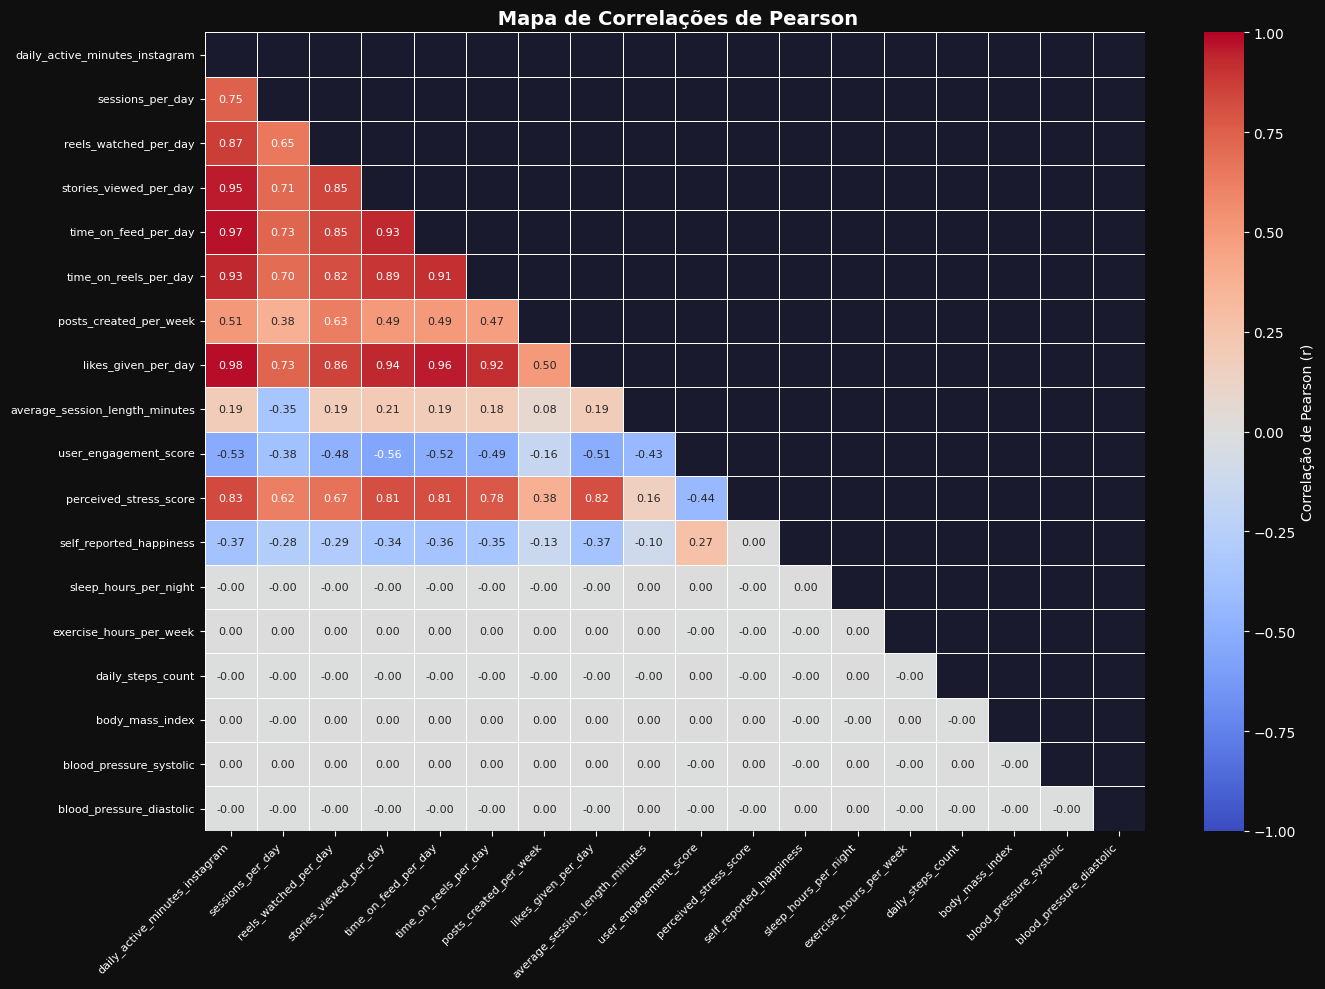

 Guardado: fig_correlacao_pearson.png


In [4]:
# ============================================================
# CORRELAÇÃO DE PEARSON
# ============================================================

# Matriz completa
corr_pearson = df[ALL_VARS].corr(method='pearson')

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'label': 'Correlação de Pearson (r)'}
)
ax.set_title(' Mapa de Correlações de Pearson', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('../data/fig_correlacao_pearson.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_correlacao_pearson.png')

In [5]:
# ============================================================
# TOP CORRELAÇÕES MAIS FORTES
# ============================================================

# Extrai pares únicos
corr_pairs = (
    corr_pearson
    .where(np.triu(np.ones(corr_pearson.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Variável A', 'Variável B', 'r (Pearson)']
corr_pairs['|r|'] = corr_pairs['r (Pearson)'].abs()
corr_pairs = corr_pairs.sort_values('|r|', ascending=False)

print(' TOP 15 CORRELAÇÕES MAIS FORTES (Pearson)\n')
print(f'{"Variável A":<40} {"Variável B":<35} {"r":>8} {"Força"}')
print('─' * 100)

def forca_correlacao(r):
    r = abs(r)
    if   r >= 0.8: return ' Muito Forte'
    elif r >= 0.6: return ' Forte'
    elif r >= 0.4: return ' Moderada'
    elif r >= 0.2: return ' Fraca'
    else:          return ' Muito Fraca'

for _, row in corr_pairs.head(15).iterrows():
    print(f'{row["Variável A"]:<40} {row["Variável B"]:<35} '
          f'{row["r (Pearson)"]:>8.4f}  {forca_correlacao(row["r (Pearson)"])}')

print('\n TOP 5 CORRELAÇÕES NEGATIVAS\n')
top_neg = corr_pairs[corr_pairs['r (Pearson)'] < 0].head(5)
for _, row in top_neg.iterrows():
    print(f'{row["Variável A"]:<40} {row["Variável B"]:<35} '
          f'{row["r (Pearson)"]:>8.4f}  {forca_correlacao(row["r (Pearson)"])}')

 TOP 15 CORRELAÇÕES MAIS FORTES (Pearson)

Variável A                               Variável B                                 r Força
────────────────────────────────────────────────────────────────────────────────────────────────────
daily_active_minutes_instagram           likes_given_per_day                   0.9809   Muito Forte
daily_active_minutes_instagram           time_on_feed_per_day                  0.9748   Muito Forte
time_on_feed_per_day                     likes_given_per_day                   0.9562   Muito Forte
daily_active_minutes_instagram           stories_viewed_per_day                0.9550   Muito Forte
stories_viewed_per_day                   likes_given_per_day                   0.9366   Muito Forte
daily_active_minutes_instagram           time_on_reels_per_day                 0.9342   Muito Forte
stories_viewed_per_day                   time_on_feed_per_day                  0.9308   Muito Forte
time_on_reels_per_day                    likes_given_per_day    

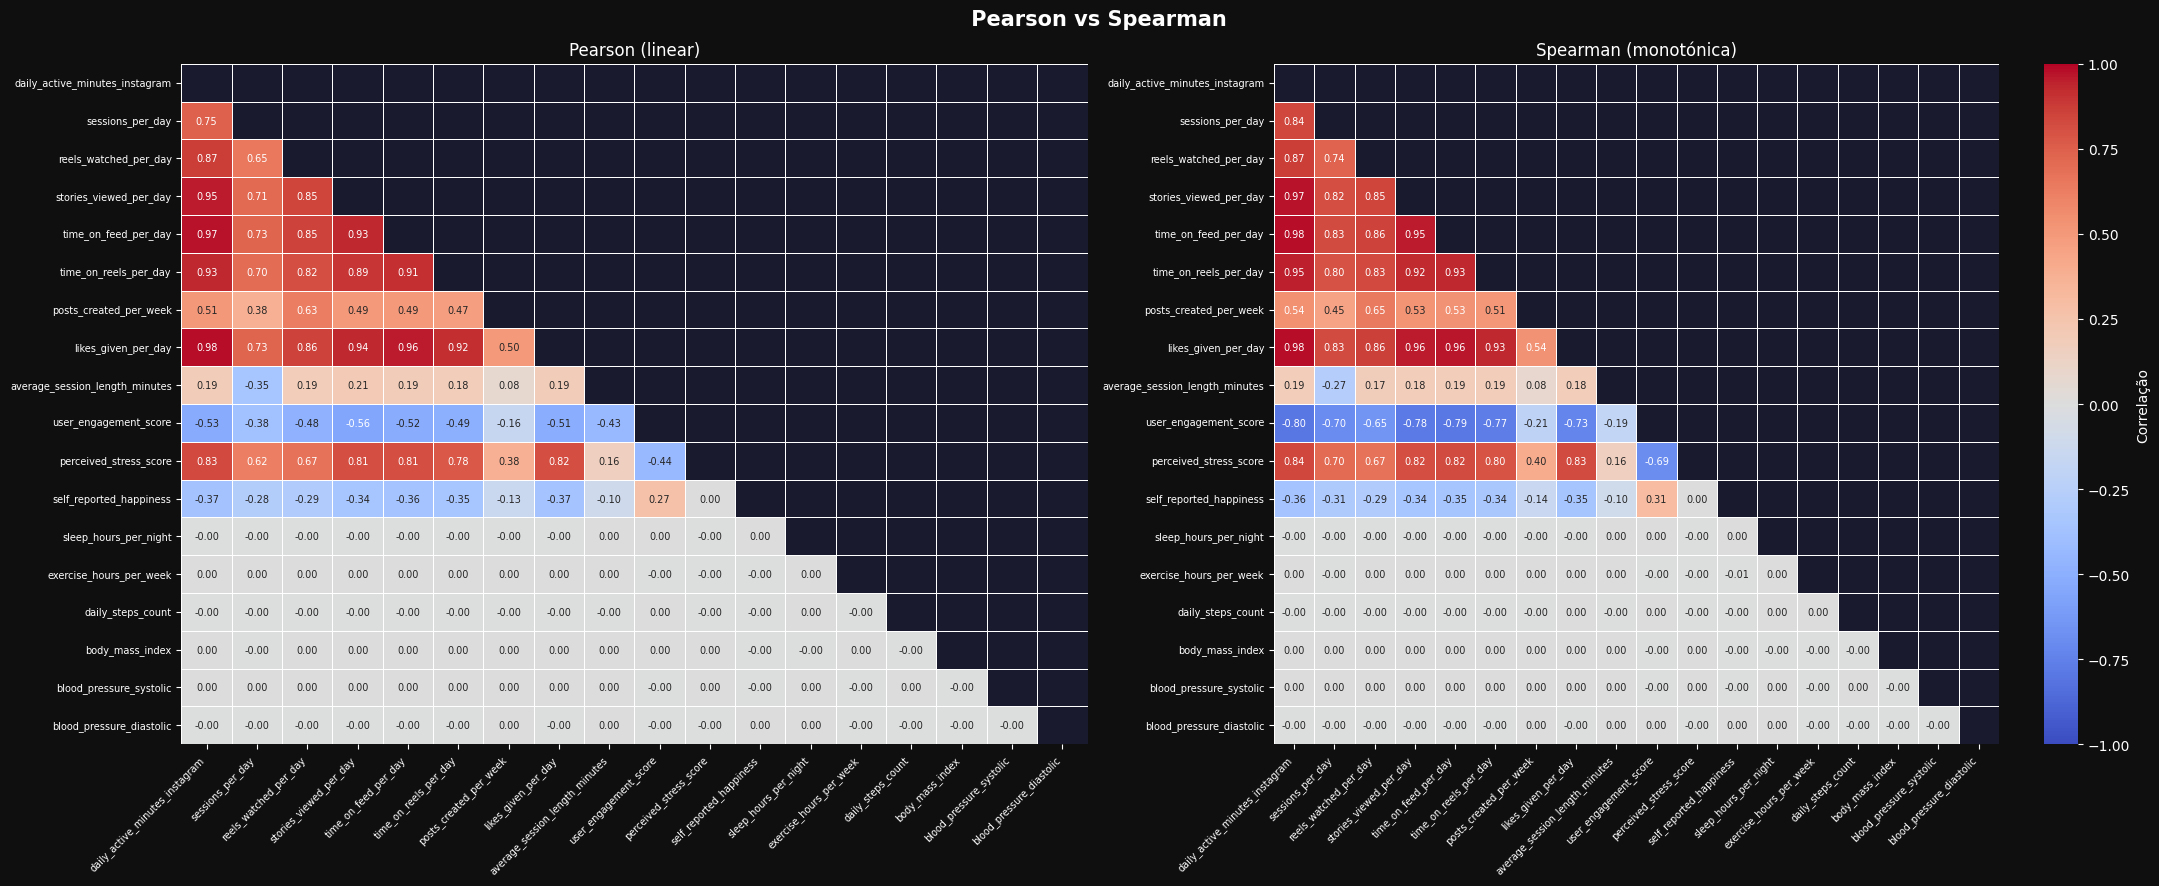

 Guardado: fig_pearson_vs_spearman.png


In [6]:
# ============================================================
# CORRELAÇÃO DE SPEARMAN
# ============================================================

corr_spearman = df[ALL_VARS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(' Pearson vs Spearman', fontsize=15, fontweight='bold')

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

# Pearson
sns.heatmap(
    corr_pearson, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, annot_kws={'size': 7},
    ax=axes[0], cbar=False
)
axes[0].set_title('Pearson (linear)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=7)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=7)

# Spearman
mask2 = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(
    corr_spearman, mask=mask2, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, annot_kws={'size': 7},
    ax=axes[1], cbar_kws={'label': 'Correlação'}
)
axes[1].set_title('Spearman (monotónica)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=7)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig('../data/fig_pearson_vs_spearman.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_pearson_vs_spearman.png')

 CORRELAÇÕES CRUZADAS: Uso do Instagram × Bem-Estar

                                perceived_stress_score  self_reported_happiness  sleep_hours_per_night  exercise_hours_per_week  daily_steps_count  body_mass_index  blood_pressure_systolic  blood_pressure_diastolic
daily_active_minutes_instagram                  0.8344                  -0.3725                -0.0010                   0.0009            -0.0012           0.0025                   0.0019                   -0.0012
sessions_per_day                                0.6233                  -0.2786                -0.0010                   0.0002            -0.0015          -0.0000                   0.0014                   -0.0004
reels_watched_per_day                           0.6748                  -0.2939                -0.0023                   0.0006            -0.0021           0.0025                   0.0023                   -0.0021
stories_viewed_per_day                          0.8140                  -0.3438        

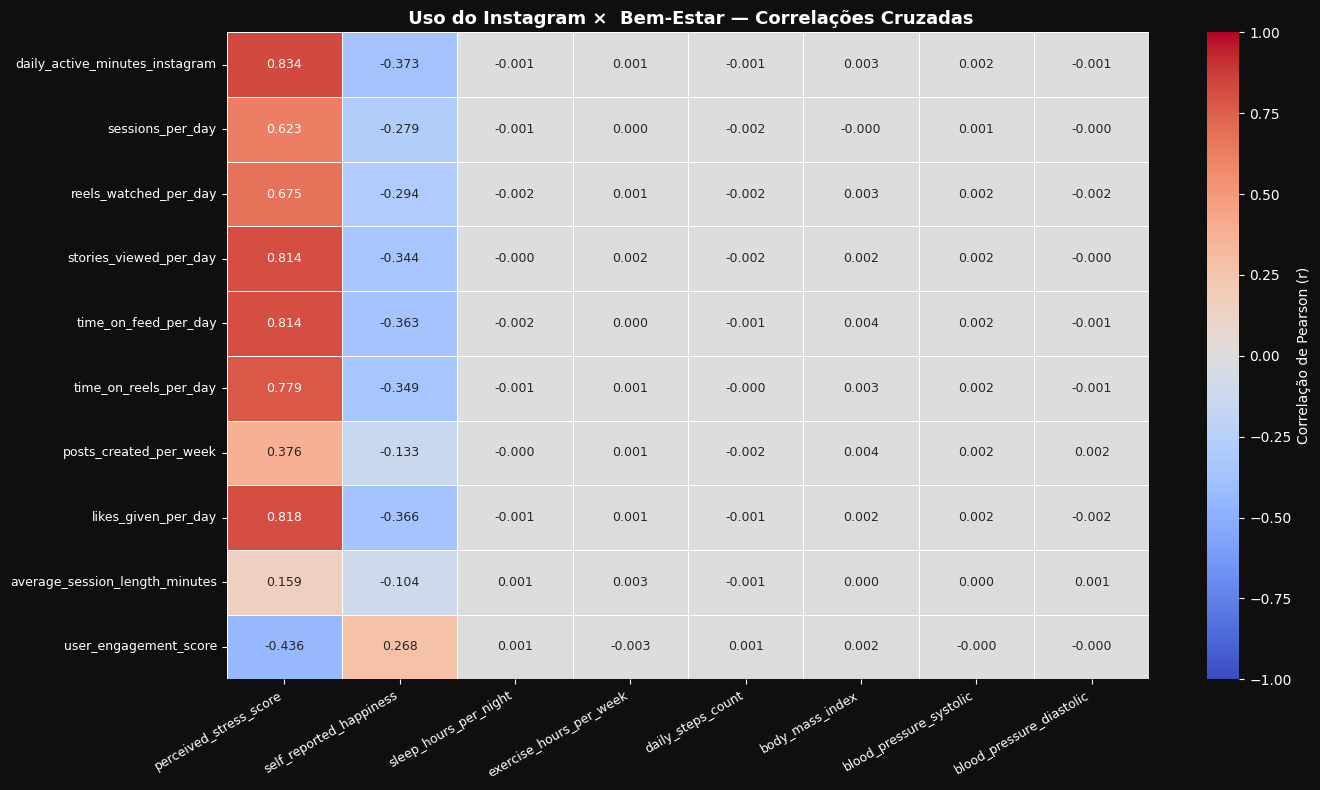

 Guardado: fig_correlacoes_cruzadas.png


In [7]:
# ============================================================
# CORRELAÇÕES CRUZADAS — USO vs BEM-ESTAR
# ============================================================

# Matriz só com uso vs bem-estar
cross_corr = df[USAGE_VARS].corrwith(df[WELLBEING_VARS[0]]).to_frame(WELLBEING_VARS[0])
for wb in WELLBEING_VARS[1:]:
    cross_corr[wb] = df[USAGE_VARS].corrwith(df[wb])

print(' CORRELAÇÕES CRUZADAS: Uso do Instagram × Bem-Estar\n')
print(cross_corr.round(4).to_string())

# Heatmap cruzado
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    cross_corr,
    annot=True, fmt='.3f',
    cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9},
    ax=ax,
    cbar_kws={'label': 'Correlação de Pearson (r)'}
)
ax.set_title(' Uso do Instagram ×  Bem-Estar — Correlações Cruzadas',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../data/fig_correlacoes_cruzadas.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_correlacoes_cruzadas.png')

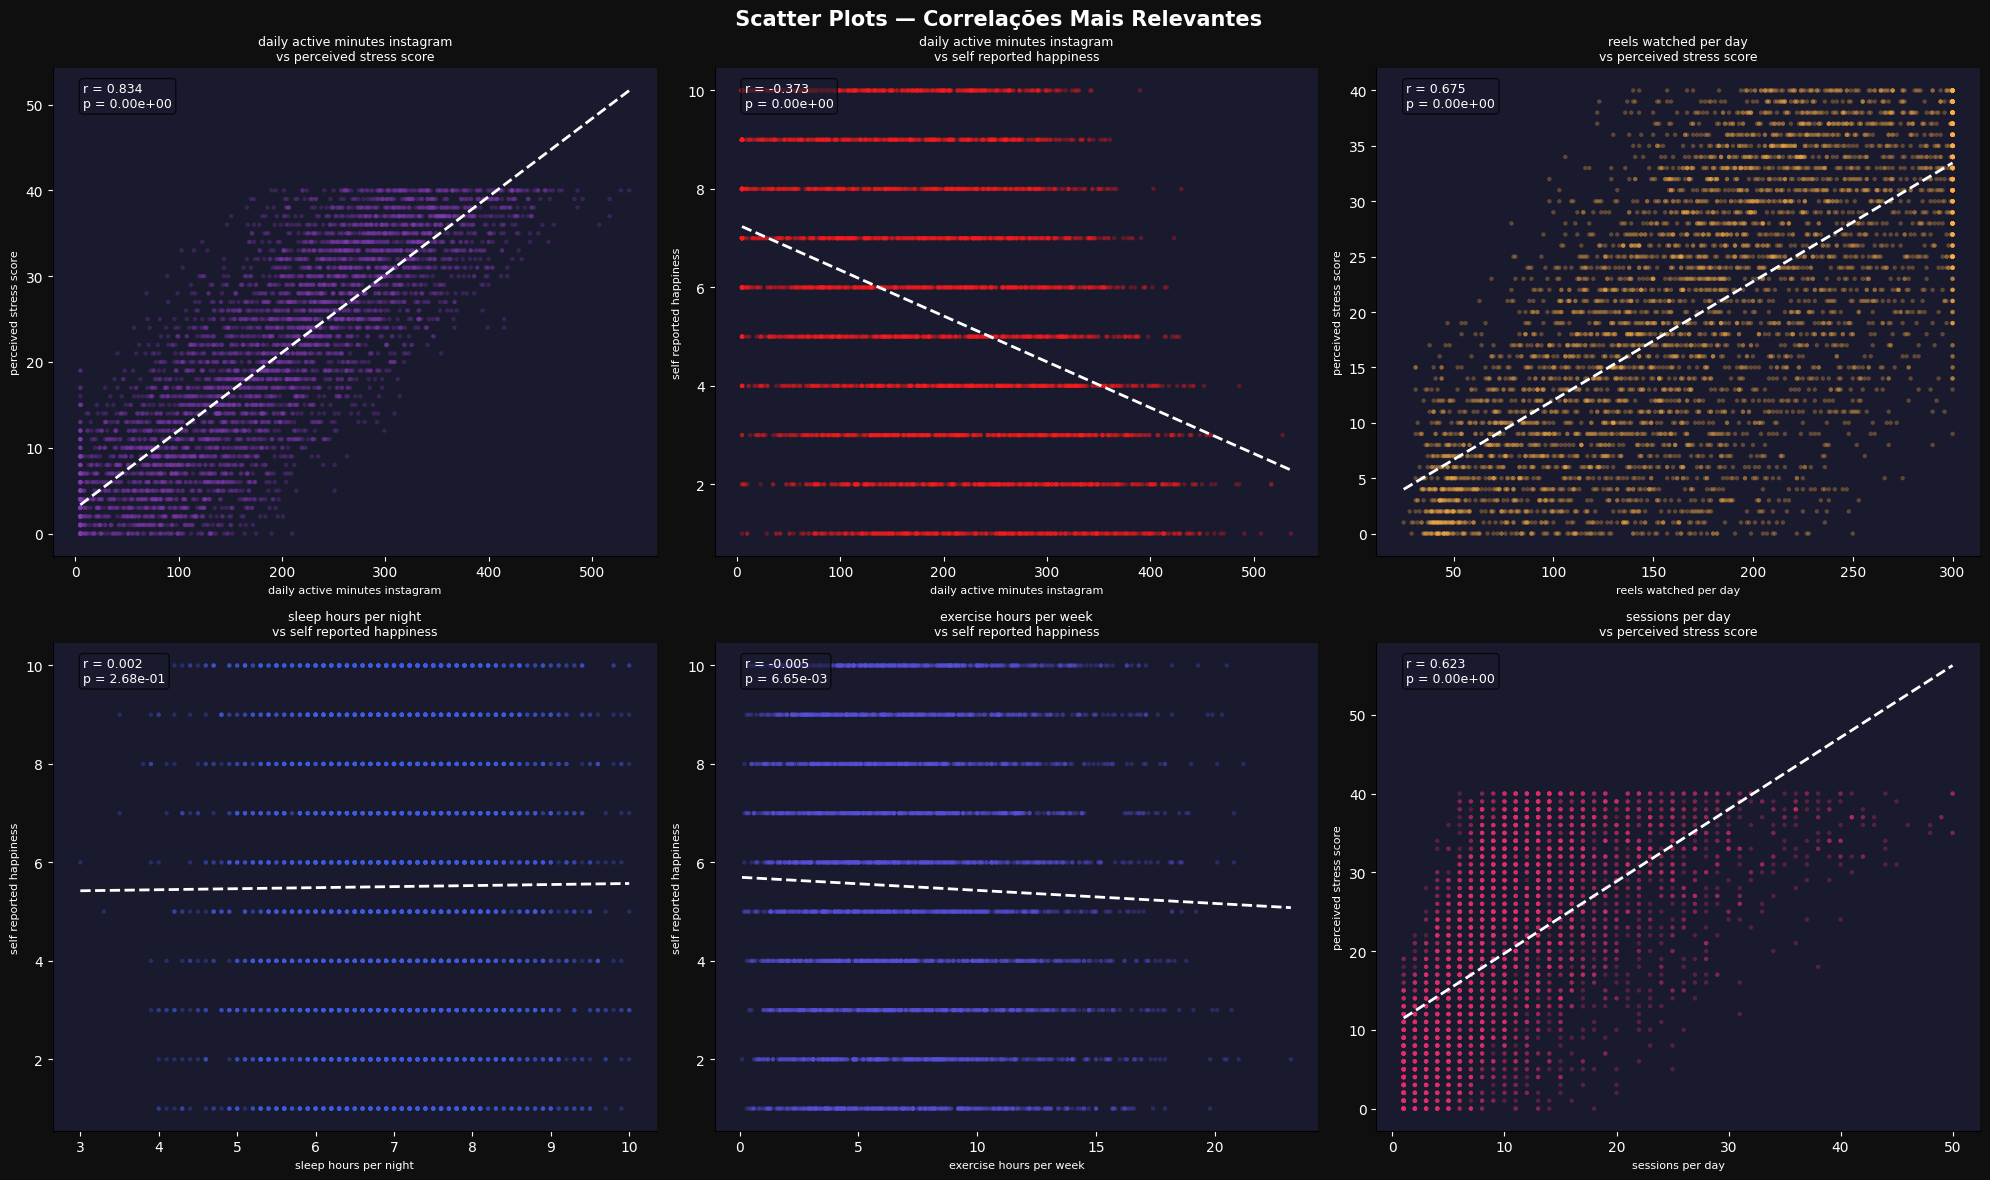

 Guardado: fig_scatter_correlacoes.png


In [8]:
# ============================================================
# SCATTER PLOTS — CORRELAÇÕES MAIS RELEVANTES
# ============================================================

PARES_SCATTER = [
    ('daily_active_minutes_instagram', 'perceived_stress_score'),
    ('daily_active_minutes_instagram', 'self_reported_happiness'),
    ('reels_watched_per_day',          'perceived_stress_score'),
    ('sleep_hours_per_night',          'self_reported_happiness'),
    ('exercise_hours_per_week',        'self_reported_happiness'),
    ('sessions_per_day',               'perceived_stress_score'),
]
PARES_SCATTER = [(a, b) for a, b in PARES_SCATTER
                 if a in df.columns and b in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(' Scatter Plots — Correlações Mais Relevantes',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

sample = df.sample(n=min(5000, len(df)), random_state=42)

for i, (x_var, y_var) in enumerate(PARES_SCATTER):
    if i >= len(axes): break

    r, p = pearsonr(df[x_var].dropna(), df[y_var].dropna())
    color = INSTA_COLORS[i % len(INSTA_COLORS)]

    axes[i].scatter(
        sample[x_var], sample[y_var],
        color=color, alpha=0.3, s=10, edgecolors='none'
    )

    # Linha de tendência
    z = np.polyfit(sample[x_var].dropna(), sample[y_var].dropna(), 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(sample[x_var].min(), sample[x_var].max(), 100)
    axes[i].plot(x_line, p_line(x_line), 'white', lw=2, ls='--')

    sig = '' if p < 0.05 else ''
    axes[i].set_title(
        f'{x_var.replace("_"," ")}\nvs {y_var.replace("_"," ")}',
        fontsize=9
    )
    axes[i].set_xlabel(x_var.replace('_',' '), fontsize=8)
    axes[i].set_ylabel(y_var.replace('_',' '), fontsize=8)
    axes[i].annotate(
        f'r = {r:.3f} {sig}\np = {p:.2e}',
        xy=(0.05, 0.92), xycoords='axes fraction',
        color='white', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.7)
    )

for j in range(len(PARES_SCATTER), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../data/fig_scatter_correlacoes.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_scatter_correlacoes.png')

In [9]:
# ============================================================
# TESTES DE HIPÓTESES
# ============================================================

print('='*70)
print('   TESTES DE HIPÓTESES')
print('='*70)

# ── H1: Stress e uso do Instagram ───────────────────────────
print('\nH1 — Utilizadores com alto stress usam mais o Instagram?')
print('─'*60)
med_stress = df['perceived_stress_score'].median()
alto  = df[df['perceived_stress_score'] >= med_stress]['daily_active_minutes_instagram'].dropna()
baixo = df[df['perceived_stress_score'] <  med_stress]['daily_active_minutes_instagram'].dropna()
t1, p1 = ttest_ind(alto, baixo)
print(f'  Média grupo alto stress  : {alto.mean():.2f} min/dia')
print(f'  Média grupo baixo stress : {baixo.mean():.2f} min/dia')
print(f'  Diferença                : {alto.mean() - baixo.mean():.2f} min/dia')
print(f'  t-statistic              : {t1:.4f}')
print(f'  p-value                  : {p1:.4e}')
print(f'  Conclusão : {" Rejeita H₀ — diferença significativa" if p1 < 0.05 else " Não rejeita H₀"}')

# ── H2: Exercício e felicidade ───────────────────────────────
print('\nH2 — Mais exercício = mais felicidade?')
print('─'*60)
med_ex   = df['exercise_hours_per_week'].median()
ativo    = df[df['exercise_hours_per_week'] >= med_ex]['self_reported_happiness'].dropna()
sedent   = df[df['exercise_hours_per_week'] <  med_ex]['self_reported_happiness'].dropna()
t2, p2   = ttest_ind(ativo, sedent)
print(f'  Média grupo ativo        : {ativo.mean():.4f}')
print(f'  Média grupo sedentário   : {sedent.mean():.4f}')
print(f'  t-statistic              : {t2:.4f}')
print(f'  p-value                  : {p2:.4e}')
print(f'  Conclusão : {" Rejeita H₀ — diferença significativa" if p2 < 0.05 else " Não rejeita H₀"}')

# ── H3: Sono e felicidade ────────────────────────────────────
print('\nH3 — Mais sono = mais felicidade? (Spearman)')
print('─'*60)
rho, p3 = spearmanr(
    df['sleep_hours_per_night'].dropna(),
    df['self_reported_happiness'].dropna()
)
print(f'  ρ (rho)   : {rho:.4f}')
print(f'  p-value   : {p3:.4e}')
print(f'  Conclusão : {" Correlação significativa" if p3 < 0.05 else " Não significativo"}')

# ── H4: Reels e stress ───────────────────────────────────────
print('\nH4 — Ver mais Reels = mais stress? (Pearson)')
print('─'*60)
r4, p4 = pearsonr(
    df['reels_watched_per_day'].dropna(),
    df['perceived_stress_score'].dropna()
)
print(f'  r (Pearson) : {r4:.4f}')
print(f'  p-value     : {p4:.4e}')
print(f'  Conclusão   : {" Correlação significativa" if p4 < 0.05 else " Não significativo"}')

# ── H5: Utilizadores premium com maior engagement ────────────
if 'uses_premium_features' in df.columns and 'user_engagement_score' in df.columns:
    print('\nH5 — Utilizadores premium têm maior engagement?')
    print('─'*60)
    premium     = df[df['uses_premium_features'] == 'Yes']['user_engagement_score'].dropna()
    nao_premium = df[df['uses_premium_features'] == 'No' ]['user_engagement_score'].dropna()
    t5, p5 = ttest_ind(premium, nao_premium)
    print(f'  Média premium     : {premium.mean():.4f}')
    print(f'  Média não-premium : {nao_premium.mean():.4f}')
    print(f'  t-statistic       : {t5:.4f}')
    print(f'  p-value           : {p5:.4e}')
    print(f'  Conclusão : {" Rejeita H₀ — diferença significativa" if p5 < 0.05 else " Não rejeita H₀"}')

   TESTES DE HIPÓTESES

H1 — Utilizadores com alto stress usam mais o Instagram?
────────────────────────────────────────────────────────────
  Média grupo alto stress  : 266.46 min/dia
  Média grupo baixo stress : 106.58 min/dia
  Diferença                : 159.88 min/dia
  t-statistic              : 577.7333
  p-value                  : 0.0000e+00
  Conclusão :  Rejeita H₀ — diferença significativa

H2 — Mais exercício = mais felicidade?
────────────────────────────────────────────────────────────
  Média grupo ativo        : 5.4721
  Média grupo sedentário   : 5.5094
  t-statistic              : -3.5545
  p-value                  : 3.7880e-04
  Conclusão :  Rejeita H₀ — diferença significativa

H3 — Mais sono = mais felicidade? (Spearman)
────────────────────────────────────────────────────────────
  ρ (rho)   : 0.0021
  p-value   : 2.4048e-01
  Conclusão :  Não significativo

H4 — Ver mais Reels = mais stress? (Pearson)
────────────────────────────────────────────────────────────
 

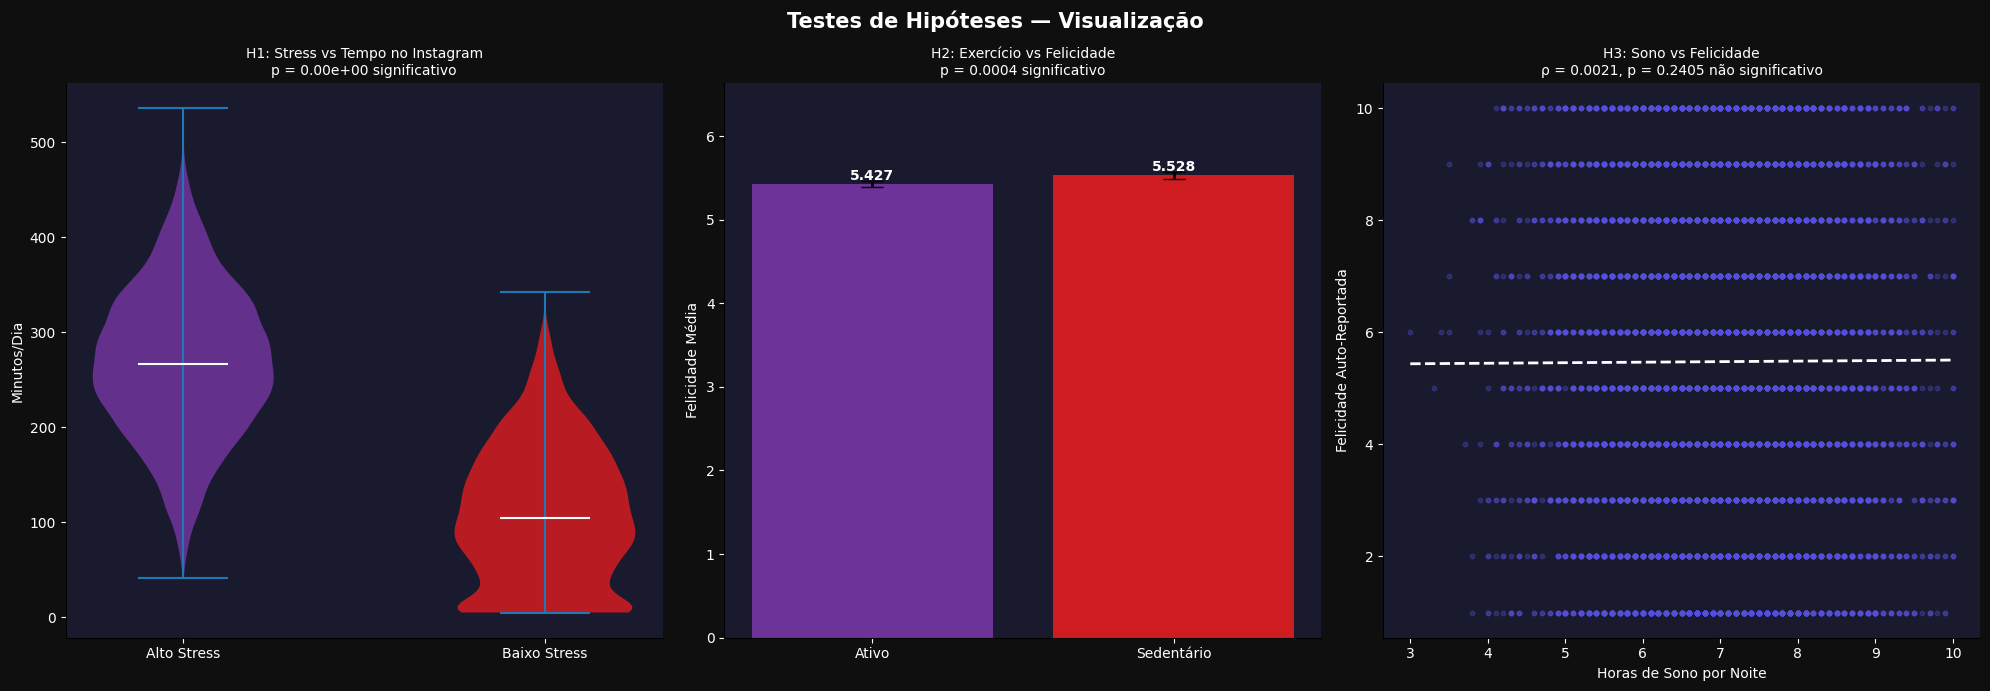

Guardado: fig_testes_hipoteses.png


In [10]:
# ============================================================
# GRÁFICO — RESUMO DOS TESTES DE HIPÓTESES
# ============================================================

# Usa amostra para o gráfico — não precisa de 273k pontos
SAMPLE_SIZE = 10_000
df_plot = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Testes de Hipóteses — Visualização', fontsize=15, fontweight='bold')

# H1 — Violinplot: stress vs uso
if all(c in df_plot.columns for c in ['perceived_stress_score', 'daily_active_minutes_instagram']):

    mediana_stress = df_plot['perceived_stress_score'].median()
    df_plot['stress_grupo'] = np.where(
        df_plot['perceived_stress_score'] >= mediana_stress,
        'Alto Stress', 'Baixo Stress'
    )

    grupos = ['Alto Stress', 'Baixo Stress']
    data_violin = [
        df_plot[df_plot['stress_grupo'] == g]['daily_active_minutes_instagram'].dropna().values
        for g in grupos
    ]

    vp = axes[0].violinplot(data_violin, positions=[1, 2], showmedians=True)
    for i, pc in enumerate(vp['bodies']):
        pc.set_facecolor(INSTA_COLORS[i])
        pc.set_alpha(0.7)
    vp['cmedians'].set_color('white')
    axes[0].set_xticks([1, 2])
    axes[0].set_xticklabels(grupos)
    sig_h1 = 'significativo' if p1 < 0.05 else 'não significativo'
    axes[0].set_title(f'H1: Stress vs Tempo no Instagram\np = {p1:.2e} {sig_h1}', fontsize=10)
    axes[0].set_ylabel('Minutos/Dia')

# H2 — Barras: exercício vs felicidade
if all(c in df_plot.columns for c in ['exercise_hours_per_week', 'self_reported_happiness']):

    mediana_ex = df_plot['exercise_hours_per_week'].median()
    df_plot['exercicio_grupo'] = np.where(
        df_plot['exercise_hours_per_week'] >= mediana_ex,
        'Ativo', 'Sedentário'
    )

    medias_h2 = df_plot.groupby('exercicio_grupo')['self_reported_happiness'].mean()
    erros_h2  = df_plot.groupby('exercicio_grupo')['self_reported_happiness'].sem()

    bars = axes[1].bar(
        medias_h2.index, medias_h2.values,
        yerr=erros_h2.values,
        color=INSTA_COLORS[:2], alpha=0.8,
        capsize=8, error_kw={'color': 'white', 'linewidth': 2}
    )
    for bar, val in zip(bars, medias_h2.values):
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.3f}', ha='center', color='white',
            fontsize=10, fontweight='bold'
        )
    sig_h2 = 'significativo' if p2 < 0.05 else 'não significativo'
    axes[1].set_title(f'H2: Exercício vs Felicidade\np = {p2:.4f} {sig_h2}', fontsize=10)
    axes[1].set_ylabel('Felicidade Média')
    axes[1].set_ylim(0, medias_h2.max() * 1.2)

# H3 — Scatter: sono vs felicidade
if all(c in df_plot.columns for c in ['sleep_hours_per_night', 'self_reported_happiness']):

    x_vals = df_plot['sleep_hours_per_night'].dropna()
    y_vals = df_plot['self_reported_happiness'].dropna()
    idx    = x_vals.index.intersection(y_vals.index)

    axes[2].scatter(
        x_vals[idx], y_vals[idx],
        color=INSTA_COLORS[4], alpha=0.3, s=10
    )

    z      = np.polyfit(x_vals[idx], y_vals[idx], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    axes[2].plot(x_line, p_line(x_line), 'white', lw=2, ls='--')

    sig_h3 = 'significativo' if p3 < 0.05 else 'não significativo'
    axes[2].set_title(f'H3: Sono vs Felicidade\nρ = {rho:.4f}, p = {p3:.4f} {sig_h3}', fontsize=10)
    axes[2].set_xlabel('Horas de Sono por Noite')
    axes[2].set_ylabel('Felicidade Auto-Reportada')

plt.tight_layout()
plt.savefig('../data/fig_testes_hipoteses.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Guardado: fig_testes_hipoteses.png')

In [11]:
# ============================================================
# EXPORTAÇÃO
# ============================================================

# Guarda correlações
corr_pearson.to_csv('../data/correlations_pearson.csv')
corr_spearman.to_csv('../data/correlations_spearman.csv')
cross_corr.to_csv('../data/correlations_cross.csv')

# Guarda resultados dos testes
testes = pd.DataFrame([
    {'Hipótese': 'H1', 'Descrição': 'Alto stress → mais Instagram',
     't/rho': round(t1,4), 'p-value': round(p1,6),
     'Conclusão': 'Rejeita H₀' if p1 < 0.05 else 'Não rejeita H₀'},
    {'Hipótese': 'H2', 'Descrição': 'Mais exercício → mais felicidade',
     't/rho': round(t2,4), 'p-value': round(p2,6),
     'Conclusão': 'Rejeita H₀' if p2 < 0.05 else 'Não rejeita H₀'},
    {'Hipótese': 'H3', 'Descrição': 'Mais sono → mais felicidade',
     't/rho': round(rho,4), 'p-value': round(p3,6),
     'Conclusão': 'Rejeita H₀' if p3 < 0.05 else 'Não rejeita H₀'},
    {'Hipótese': 'H4', 'Descrição': 'Mais Reels → mais stress',
     't/rho': round(r4,4), 'p-value': round(p4,6),
     'Conclusão': 'Rejeita H₀' if p4 < 0.05 else 'Não rejeita H₀'},
])
testes.to_csv('../data/hypothesis_tests.csv', index=False)

print(' Correlações exportadas: correlations_pearson.csv, correlations_spearman.csv')
print(' Testes exportados     : hypothesis_tests.csv')

 Correlações exportadas: correlations_pearson.csv, correlations_spearman.csv
 Testes exportados     : hypothesis_tests.csv


# Análise Crítica

## Principais Conclusões

- Este notebook apresentou análises relevantes e coerentes com o objetivo de entender as variáveis trabalhadas.
- Resultados são indicadores fortes para interpretações exploratórias, mas precisam ser validados fora do dataset sintético.

## Limitações

- Dataset sintético reduz generalização para cenários reais.
- Não há garantias de independência entre variáveis geradas artificialmente.
- Não existe análise temporal profunda no conjunto atual.

## Recomendação

- Complementar com dados reais e amostras representativas.
- Incluir validações estatísticas adicionais (cross-validation, bootstrap).
- Documentar impactos das transformações e critérios de limpeza.
